# Explainable AML modeling — simple MVP

This notebook compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on **every row** of IBM's synthetic HI-Small transactions. It builds four account-history features from strictly earlier activity, uses a time-ordered train/validation/test split, and gives each model its own results and explanation. XGBoost includes global and local **Tree SHAP** charts. Run cells from top to bottom.

This is a class demonstration on **synthetic data**. A high score suggests a transaction for review; it is not an investigator conclusion or a calibrated laundering probability. The [project guide](docs/PROJECT_GUIDE.md) explains the choices and limits. Tables and charts stay in this notebook.


## 1. Imports and settings

Put `HI-Small_Trans.csv` at `data/raw/HI-Small_Trans.csv` as described in the [README](README.md). The notebook reads the entire CSV. The seed keeps model fitting and the small SHAP illustration reproducible.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SEED = 42
print("Dataset:", DATA_PATH)
print("Rows: entire CSV")


Dataset: data/raw/HI-Small_Trans.csv
Rows: entire CSV


## 2. Load every transaction

The CSV has about five million rows. Every row enters the account history and one of the three modeling periods. The smaller table below keeps the columns needed for modeling; bank and account IDs are used to make relationship history and same-bank/account flags, then dropped as raw identifiers. The final September 11–18 rows are kept, but their unusual label balance is shown separately later.


In [2]:
transaction_parts = []
history_parts = []
raw_rows = raw_positives = 0
for chunk in pd.read_csv(
    DATA_PATH,
    chunksize=100_000,
    usecols=["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
             "Amount Received", "Receiving Currency", "Amount Paid",
             "Payment Currency", "Payment Format", "Is Laundering"],
    dtype={"From Bank": str, "Account": str, "To Bank": str, "Account.1": str},
):
    timestamps = pd.to_datetime(chunk["Timestamp"])
    source_rows = np.arange(raw_rows, raw_rows + len(chunk), dtype=np.int32)
    same_bank = chunk["From Bank"].to_numpy() == chunk["To Bank"].to_numpy()
    same_account = same_bank & (
        chunk["Account"].to_numpy() == chunk["Account.1"].to_numpy()
    )
    transaction_parts.append(pd.DataFrame({
        "source_row": source_rows,
        "timestamp": timestamps.to_numpy(),
        "amount_paid": chunk["Amount Paid"].to_numpy(),
        "amount_received": chunk["Amount Received"].to_numpy(),
        "payment_currency": chunk["Payment Currency"].to_numpy(),
        "receiving_currency": chunk["Receiving Currency"].to_numpy(),
        "payment_format": chunk["Payment Format"].to_numpy(),
        "label": chunk["Is Laundering"].to_numpy(dtype=np.int8),
        "same_bank": same_bank.astype(np.int8),
        "same_account": same_account.astype(np.int8),
    }))
    history_parts.append(pd.DataFrame({
        "source_row": source_rows,
        "timestamp": timestamps.to_numpy(),
        "sender": (chunk["From Bank"] + ":" + chunk["Account"]).to_numpy(),
        "receiver": (chunk["To Bank"] + ":" + chunk["Account.1"]).to_numpy(),
        "amount_paid": chunk["Amount Paid"].to_numpy(),
        "currency": chunk["Payment Currency"].to_numpy(),
    }))
    raw_rows += len(chunk)
    raw_positives += int(chunk["Is Laundering"].sum())

transactions = pd.concat(transaction_parts, ignore_index=True)
history = pd.concat(history_parts, ignore_index=True)
for column in ["payment_currency", "receiving_currency", "payment_format"]:
    transactions[column] = transactions[column].astype("category")
del transaction_parts, history_parts, chunk

label_balance = pd.DataFrame({
    "rows": [raw_rows],
    "positive_labels": [raw_positives],
    "negative_labels": [raw_rows - raw_positives],
    "positive_pct": [100 * raw_positives / raw_rows],
    "negative_pct": [100 * (raw_rows - raw_positives) / raw_rows],
}, index=["full CSV / modeled rows"])
print(f"Transactions modeled: {len(transactions):,}; history rows: {len(history):,}")
display(label_balance.round(4))


Transactions modeled: 5,078,345; history rows: 5,078,345


,rows,positive_labels,negative_labels,positive_pct,negative_pct
full CSV / modeled rows,5078345,5177,5073168,0.1019,99.8981


## 3. Create features from strictly earlier transactions

We keep four simple history features: earlier sender count, receiver count, sender–receiver pair count, and the sender's earlier average payment in the same currency. They use **all transactions before the current timestamp**. Rows at the same timestamp do not count one another. Bank and account IDs connect past activity but are not passed to the models as raw identifiers.


In [3]:
# Give each account one numeric ID, whether it sends or receives.
accounts = pd.concat([history["sender"], history["receiver"]], ignore_index=True)
account_ids, _ = pd.factorize(accounts, sort=False)
n = len(history)
history["sender_id"] = account_ids[:n].astype(np.int32)
history["receiver_id"] = account_ids[n:].astype(np.int32)
history["currency_id"] = pd.factorize(history["currency"], sort=False)[0].astype(np.int8)
history = history.drop(columns=["sender", "receiver", "currency"])
del accounts, account_ids

history = history.sort_values("timestamp", kind="stable").reset_index(drop=True)

# Subtract rows at the same timestamp so every count means strictly earlier.
for group, name in [
    (["sender_id"], "prior_sender_count"),
    (["receiver_id"], "prior_receiver_count"),
    (["sender_id", "receiver_id"], "prior_pair_count"),
]:
    history[name] = (
        history.groupby(group, sort=False).cumcount()
        - history.groupby(group + ["timestamp"], sort=False).cumcount()
    ).astype(np.int32)

keys = ["sender_id", "currency_id"]
earlier_amount = (
    history.groupby(keys, sort=False)["amount_paid"].cumsum()
    - history.groupby(keys + ["timestamp"], sort=False)["amount_paid"].cumsum()
)
earlier_count = (
    history.groupby(keys, sort=False).cumcount()
    - history.groupby(keys + ["timestamp"], sort=False).cumcount()
)
history["log_prior_sender_mean_amount"] = np.log1p(
    earlier_amount / earlier_count.replace(0, np.nan)
).fillna(0).astype(np.float32)

history_columns = [
    "prior_sender_count", "prior_receiver_count", "prior_pair_count",
    "log_prior_sender_mean_amount",
]
# Put history values back into the CSV's original row order.
positions = history["source_row"].to_numpy()
for column in history_columns:
    values = np.empty(len(history), dtype=history[column].dtype)
    values[positions] = history[column].to_numpy()
    transactions[column] = values
del history, positions, values, earlier_amount, earlier_count

transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)
transactions["log_amount"] = np.log1p(transactions["amount_paid"]).astype(np.float32)
transactions["log_amount_received"] = np.log1p(transactions["amount_received"]).astype(np.float32)
transactions["hour"] = transactions["timestamp"].dt.hour.astype(np.int8)
transactions = transactions.drop(columns=["source_row", "amount_paid", "amount_received"])
print("Earlier-history feature example:")
display(transactions[history_columns].head())


Earlier-history feature example:


,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount
0,0,0,0,0.0
1,0,0,0,0.0
2,0,0,0,0.0
3,0,0,0,0.0
4,0,0,0,0.0


## 4. Split by time and prepare model inputs

Training uses September 1–6, validation September 7–8, and the later test September 9–18. The test includes **every remaining row**. We show September 9–10 and the sharply different September 11–18 tail separately. Each history feature uses only earlier activity. Payment format and currencies become 0/1 columns.

Logistic regression is linear, so we also compress the three large count ranges with `log1p` and add three readable behavior clues: whether the sender has appeared before, whether this sender–receiver pair has appeared before, and the gap between this payment and the sender's earlier typical payment. The gap is zero when there is no earlier sender history. XGBoost and EBM use the original encoded inputs. All three use the same source transactions and labels.


In [4]:
feature_columns = [
    "log_amount", "log_amount_received", "hour", "same_bank", "same_account",
    "prior_sender_count", "prior_receiver_count", "prior_pair_count",
    "log_prior_sender_mean_amount", "payment_format", "payment_currency",
    "receiving_currency",
]
categories = ["payment_format", "payment_currency", "receiving_currency"]
train = transactions.loc[transactions["timestamp"] < "2022-09-07"].copy()
validation = transactions.loc[
    (transactions["timestamp"] >= "2022-09-07") &
    (transactions["timestamp"] < "2022-09-09")
].copy()
test = transactions.loc[transactions["timestamp"] >= "2022-09-09"].copy()

split_summary = pd.DataFrame({
    "period": ["train", "validation", "test"],
    "rows": [len(train), len(validation), len(test)],
    "positive_labels": [train["label"].sum(), validation["label"].sum(), test["label"].sum()],
})
split_summary["share_of_all_rows_pct"] = (100 * split_summary["rows"] / len(transactions)).round(2)
split_summary["positive_label_rate_pct"] = (100 * split_summary["positive_labels"] / split_summary["rows"]).round(4)
display(split_summary)

test_period_summary = pd.DataFrame({
    "period": ["September 9–10", "September 11–18"],
    "rows": [int((test["timestamp"] < "2022-09-11").sum()),
             int((test["timestamp"] >= "2022-09-11").sum())],
    "positive_labels": [int(test.loc[test["timestamp"] < "2022-09-11", "label"].sum()),
                        int(test.loc[test["timestamp"] >= "2022-09-11", "label"].sum())],
})
test_period_summary["positive_label_rate_pct"] = (
    100 * test_period_summary["positive_labels"] / test_period_summary["rows"]
)
print("Two different parts of the later test:")
display(test_period_summary.round(4))
del transactions

X_train = pd.get_dummies(train[feature_columns], columns=categories, dtype=np.float32).astype(np.float32)
X_validation = pd.get_dummies(validation[feature_columns], columns=categories, dtype=np.float32)
X_test = pd.get_dummies(test[feature_columns], columns=categories, dtype=np.float32)
X_validation = X_validation.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype(np.float32)
y_train = train["label"]
y_validation = validation["label"]
y_test = test["label"]
# Give the linear model a simple shape for heavy-tailed history counts.
def logistic_inputs(encoded, frame):
    x = encoded.copy()
    for column in ["prior_sender_count", "prior_receiver_count", "prior_pair_count"]:
        x[column] = np.log1p(x[column])
    seen_sender = frame["prior_sender_count"].to_numpy() > 0
    gap = np.abs(
        frame["log_amount"].to_numpy()
        - frame["log_prior_sender_mean_amount"].to_numpy()
    )
    x["amount_vs_sender_usual"] = np.where(seen_sender, gap, 0).astype(np.float32)
    x["seen_sender_before"] = seen_sender.astype(np.float32)
    x["seen_pair_before"] = (frame["prior_pair_count"].to_numpy() > 0).astype(np.float32)
    return x

X_train_logistic = logistic_inputs(X_train, train)
X_validation_logistic = logistic_inputs(X_validation, validation)
X_test_logistic = logistic_inputs(X_test, test)
print("XGBoost/EBM inputs:", len(X_train.columns),
      "| logistic inputs:", len(X_train_logistic.columns))
display(X_train_logistic.head())


,period,rows,positive_labels,share_of_all_rows_pct,positive_label_rate_pct
0,train,3248921,2530,63.98,0.0779
1,validation,965524,1036,19.01,0.1073
2,test,863900,1611,17.01,0.1865


Two different parts of the later test:


,period,rows,positive_labels,positive_label_rate_pct
0,September 9–10,862792,956,0.1108
1,September 11–18,1108,655,59.1155


XGBoost/EBM inputs: 46 | logistic inputs: 49


,log_amount,log_amount_received,hour,same_bank,same_account,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount,payment_format_ACH,...,receiving_currency_Saudi Riyal,receiving_currency_Shekel,receiving_currency_Swiss Franc,receiving_currency_UK Pound,receiving_currency_US Dollar,receiving_currency_Yen,receiving_currency_Yuan,amount_vs_sender_usual,seen_sender_before,seen_pair_before
0,9.594007,9.594007,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,6.800582,6.800582,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,11.512805,11.512805,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2.837908,2.837908,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2.424803,2.424803,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## 5. Define three understandable models

- **Logistic regression:** one weighted sum of standardized inputs. Its coefficients show which inputs raise or lower the score.
- **XGBoost:** a small collection of shallow decision trees (`max_depth=3`). Tree SHAP will show which inputs moved scores for a sample and a specific transaction.
- **EBM:** one smooth score contribution per input, with interactions turned off. Its additive terms can be inspected directly.

All three give rare positive labels a moderate training weight of 10. Scores are ranking tools, not calibrated laundering probabilities.

In [5]:
positive_weight = 10
models = {
    "Logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=500)
    ),
    "XGBoost": XGBClassifier(
        n_estimators=120, max_depth=3, learning_rate=0.08,
        scale_pos_weight=positive_weight, tree_method="hist", n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=200, n_jobs=4, random_state=SEED
    ),
}


## 6. Time-ordered cross-validation inside training

We now **run** three expanding windows: fit on September 1–3 and check September 4; fit on September 1–4 and check September 5; fit on September 1–5 and check September 6. Each fold learns category columns, logistic scaling, and model weights from its earlier fit rows. Full-history features use only transactions before each row, so later labels and activity cannot enter an earlier row's features. Mean average precision (AP) across these folds selects the model family. September 7–8 remains separate for threshold selection, and September 9–18 is reported afterward, with September 9–10 and September 11–18 shown separately. This is time-ordered validation, not stratified K-fold.


In [6]:
fold_rows = []
for name, model in models.items():
    for fit_end, check_end in [
        ("2022-09-04", "2022-09-05"),
        ("2022-09-05", "2022-09-06"),
        ("2022-09-06", "2022-09-07"),
    ]:
        fold_train = train.loc[train["timestamp"] < fit_end]
        fold_check = train.loc[
            (train["timestamp"] >= fit_end) & (train["timestamp"] < check_end)
        ]
        X_fit = pd.get_dummies(
            fold_train[feature_columns], columns=categories, dtype=np.float32
        ).astype(np.float32)
        X_check = pd.get_dummies(
            fold_check[feature_columns], columns=categories, dtype=np.float32
        ).reindex(columns=X_fit.columns, fill_value=0).astype(np.float32)
        y_fit = fold_train["label"]
        weights = np.where(y_fit == 1, positive_weight, 1.0)
        fitted = clone(model)
        if name == "Logistic regression":
            X_fit = logistic_inputs(X_fit, fold_train)
            X_check = logistic_inputs(X_check, fold_check)
            fitted.fit(X_fit, y_fit, logisticregression__sample_weight=weights)
        elif name == "EBM":
            fitted.fit(X_fit, y_fit, sample_weight=weights)
        else:
            fitted.fit(X_fit, y_fit)
        fold_rows.append({
            "model": name,
            "check_day": fit_end,
            "positive_labels": int(fold_check["label"].sum()),
            "average_precision": average_precision_score(
                fold_check["label"], fitted.predict_proba(X_check)[:, 1]
            ),
        })

fold_results = pd.DataFrame(fold_rows)
fold_summary = fold_results.pivot(
    index="model", columns="check_day", values="average_precision"
)
fold_summary["mean_ap"] = fold_summary.mean(axis=1)
fold_summary = fold_summary.sort_values("mean_ap", ascending=False)
selected_model = fold_summary.index[0]
print("Positive labels in the three check days:")
display(fold_results.groupby("check_day")["positive_labels"].first())
print("Average precision by time fold:")
display(fold_summary.round(4))
print("Selected model:", selected_model)

Positive labels in the three check days:


check_day
2022-09-04    407
2022-09-05    471
2022-09-06    531
Name: positive_labels, dtype: int64

Average precision by time fold:


check_day,2022-09-04,2022-09-05,2022-09-06,mean_ap
model,,,,
XGBoost,0.4124,0.4332,0.4886,0.4448
EBM,0.3868,0.3994,0.4543,0.4135
Logistic regression,0.2584,0.2798,0.2995,0.2792


Selected model: XGBoost


## 7. Fit the final models on September 1–6

After the time folds, we fit fresh versions of all three models on **all six training days**. The September 7–8 labels are not used for fitting. Each model still gets a scorecard later in the notebook.

In [7]:
weights = np.where(y_train == 1, positive_weight, 1.0)
models["Logistic regression"].fit(
    X_train_logistic, y_train, logisticregression__sample_weight=weights
)
models["XGBoost"].fit(X_train, y_train)
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted on all September 1-6 rows:", ", ".join(models))

Fitted on all September 1-6 rows: Logistic regression, XGBoost, EBM


## 8. Choose thresholds and evaluate later activity

**Average precision (AP, a summary of the precision–recall curve)** evaluates ranking across thresholds. For rare labels, the positive-label rate is its random-ranking baseline. **Precision, recall, and F1** evaluate binary alerts at a stated threshold. **False positive rate (FPR)** is false alerts divided by all normal transactions; the confusion matrix gives the counts. The model was selected using the earlier time folds. Logistic regression and EBM use the threshold with the best F1 on September 7–8. To increase detection while keeping a majority of alerts useful, XGBoost uses the validation threshold with the **highest recall among thresholds with at least 70% precision**. We also show its F1-optimal alternative so the recall and alert-workload tradeoff is visible. Every threshold is chosen on September 7–8 and then applied unchanged to all September 9–18 rows. We also report September 9–10 and the distribution-shifted September 11–18 tail separately.

The **illustrative class-project goal**, chosen for the ordinary September 9–10 test days, is at least **30% precision, 30% recall, 0.30 F1**, and **FPR below 0.1%**. These values are not regulatory or industry minimums. Precision and recall are explicitly discussed in industry AML guidance; F1, FPR, and AP are useful statistical measures for this labeled experiment. Actual risk coverage and SAR quality cannot be measured from this CSV. A bank would set outcomes against its own risk coverage, investigation capacity, and alert quality. The [Wolfsberg Group](https://wolfsberg-group.org/resources/195/202) recommends considering precision, recall, priority-risk coverage, and SAR quality; the [FFIEC manual](https://bsaaml.ffiec.gov/manual/AssessingComplianceWithBSARegulatoryRequirements/04) describes risk-based monitoring and review rather than numeric model cutoffs.


In [8]:
rows = []
scores = {}
thresholds = {}
f1_thresholds = {}
for name, model in models.items():
    X_val = X_validation_logistic if name == "Logistic regression" else X_validation
    X_later = X_test_logistic if name == "Logistic regression" else X_test
    validation_score = model.predict_proba(X_val)[:, 1]
    precision_curve, recall_curve, cutoff_values = precision_recall_curve(
        y_validation, validation_score
    )
    f1_curve = (
        2 * precision_curve[:-1] * recall_curve[:-1]
        / (precision_curve[:-1] + recall_curve[:-1] + 1e-12)
    )
    f1_thresholds[name] = cutoff_values[np.argmax(f1_curve)]
    if name == "XGBoost":
        high_precision = np.where(precision_curve[:-1] >= 0.70)[0]
        thresholds[name] = cutoff_values[high_precision[np.argmax(recall_curve[high_precision])]]
    else:
        thresholds[name] = f1_thresholds[name]

    for period, X, y in [
        ("validation", X_val, y_validation),
        ("test", X_later, y_test),
    ]:
        score = validation_score if period == "validation" else model.predict_proba(X)[:, 1]
        scores[(name, period)] = score
        alerts = score >= thresholds[name]
        tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
        rows.append({
            "model": name,
            "period": period,
            "average_precision": average_precision_score(y, score),
            "precision": precision_score(y, alerts, zero_division=0),
            "recall": recall_score(y, alerts),
            "f1": f1_score(y, alerts),
            "false_positive_rate": fp / (fp + tn),
            "true_positives": int(tp),
            "false_positives": int(fp),
            "alerts": int(alerts.sum()),
        })
results = pd.DataFrame(rows)
# Report both parts of the later test, because their label rates differ sharply.
period_rows = []
for name in models:
    for period, mask in [
        ("September 9–10", (test["timestamp"] < "2022-09-11").to_numpy()),
        ("September 11–18", (test["timestamp"] >= "2022-09-11").to_numpy()),
    ]:
        y_part = y_test.to_numpy()[mask]
        score_part = scores[(name, "test")][mask]
        alerts = score_part >= thresholds[name]
        tn, fp, fn, tp = confusion_matrix(y_part, alerts).ravel()
        period_rows.append({
            "model": name, "period": period, "rows": len(y_part),
            "positive_labels": int(y_part.sum()),
            "average_precision": average_precision_score(y_part, score_part),
            "precision": precision_score(y_part, alerts, zero_division=0),
            "recall": recall_score(y_part, alerts),
            "f1": f1_score(y_part, alerts),
            "false_positive_rate": fp / (fp + tn),
            "true_positives": int(tp), "false_positives": int(fp),
            "alerts": int(alerts.sum()),
        })
period_results = pd.DataFrame(period_rows)
print("Selected using time-fold mean AP:", selected_model)
print("Positive-label rate: validation", round(y_validation.mean(), 4),
      "reporting period", round(y_test.mean(), 4))
display(results.round(4))
print("Later test, split by the shift in label balance:")
display(period_results.round(4))
selected_alerts = scores[(selected_model, "test")] >= thresholds[selected_model]
print("Validation-selected threshold for", selected_model, ":", round(thresholds[selected_model], 4))
display(pd.DataFrame(
    confusion_matrix(y_test, selected_alerts),
    index=["actual normal", "actual laundering"],
    columns=["no alert", "alert"],
))

later = period_results[(period_results["model"] == selected_model) & (period_results["period"] == "September 9–10")].iloc[0]
print("Illustrative class-project goal on September 9–10:")
for metric, target in [("precision", 0.30), ("recall", 0.30), ("f1", 0.30)]:
    print(f"{metric}: {later[metric]:.2%} (goal at least {target:.0%}) —",
          "met" if later[metric] >= target else "not met")
print(f"false positive rate: {later['false_positive_rate']:.3%} (goal below 0.1%) —",
      "met" if later["false_positive_rate"] < 0.001 else "not met")

# The same XGBoost ranking can produce more recall by reviewing more alerts.
xgb_p, xgb_r, xgb_cutoffs = precision_recall_curve(
    y_validation, scores[("XGBoost", "validation")]
)
threshold_options = [
    ("Best validation F1", f1_thresholds["XGBoost"]),
    ("More recall, at least 70% validation precision (chosen)", thresholds["XGBoost"]),
]
tradeoff_rows = []
for policy, threshold in threshold_options:
    for period, y, score in [
        ("validation", y_validation, scores[("XGBoost", "validation")]),
        ("test", y_test, scores[("XGBoost", "test")]),
    ]:
        alerts = score >= threshold
        tn, fp, fn, tp = confusion_matrix(y, alerts).ravel()
        tradeoff_rows.append({
            "policy": policy, "period": period, "threshold": threshold,
            "precision": tp / (tp + fp), "recall": tp / (tp + fn),
            "f1": 2 * tp / (2 * tp + fp + fn),
            "false_positive_rate": fp / (fp + tn),
            "alerts": int(tp + fp), "true_positives": int(tp),
            "false_positives": int(fp),
        })
print("XGBoost recall versus alert workload (all choices use validation only):")
display(pd.DataFrame(tradeoff_rows).round(4))



Selected using time-fold mean AP: XGBoost
Positive-label rate: validation 0.0011 reporting period 0.0019


,model,period,average_precision,precision,recall,f1,false_positive_rate,true_positives,false_positives,alerts
0,Logistic regression,validation,0.2884,0.4589,0.3069,0.3678,0.0004,318,375,693
1,Logistic regression,test,0.4291,0.5427,0.4066,0.4649,0.0006,655,552,1207
2,XGBoost,validation,0.4738,0.7009,0.3890,0.5003,0.0002,403,172,575
3,XGBoost,test,0.5876,0.7983,0.4767,0.5970,0.0002,768,194,962
4,EBM,validation,0.4293,0.8201,0.3301,0.4708,0.0001,342,75,417
5,EBM,test,0.5301,0.8434,0.3743,0.5185,0.0001,603,112,715


Later test, split by the shift in label balance:


,model,period,rows,positive_labels,average_precision,precision,recall,f1,false_positive_rate,true_positives,false_positives,alerts
0,Logistic regression,September 9–10,862792,956,0.2827,0.3719,0.3295,0.3494,0.0006,315,532,847
1,Logistic regression,September 11–18,1108,655,0.9395,0.9444,0.5191,0.6700,0.0442,340,20,360
2,XGBoost,September 9–10,862792,956,0.4625,0.7058,0.3964,0.5077,0.0002,379,158,537
3,XGBoost,September 11–18,1108,655,0.9306,0.9153,0.5939,0.7204,0.0795,389,36,425
4,EBM,September 9–10,862792,956,0.4167,0.7905,0.3117,0.4471,0.0001,298,79,377
5,EBM,September 11–18,1108,655,0.9264,0.9024,0.4656,0.6143,0.0728,305,33,338


Validation-selected threshold for XGBoost : 0.3704


,no alert,alert
actual normal,862095,194
actual laundering,843,768


Illustrative class-project goal on September 9–10:
precision: 70.58% (goal at least 30%) — met
recall: 39.64% (goal at least 30%) — met
f1: 50.77% (goal at least 30%) — met
false positive rate: 0.018% (goal below 0.1%) — met


XGBoost recall versus alert workload (all choices use validation only):


,policy,period,threshold,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
0,Best validation F1,validation,0.3981,0.7640,0.3813,0.5087,0.0001,517,395,122
1,Best validation F1,test,0.3981,0.8433,0.4544,0.5906,0.0002,868,732,136
2,"More recall, at least 70% validation precision...",validation,0.3704,0.7009,0.3890,0.5003,0.0002,575,403,172
3,"More recall, at least 70% validation precision...",test,0.3704,0.7983,0.4767,0.5970,0.0002,962,768,194


### 8.1 Where does the selected model miss positive labels?

These tables show the selected model's alert quality by payment format and day. Small groups have uncertain rates, so focus on the positive and alert counts. We inspect the later period, including the unusual September 11–18 tail to understand limitations; we do not use it to choose the model or threshold.


In [9]:
format_rows = []
day_rows = []
for period, frame, score, threshold in [
    ("validation", validation, scores[(selected_model, "validation")], thresholds[selected_model]),
    ("test", test, scores[(selected_model, "test")], thresholds[selected_model]),
]:
    review = frame[["timestamp", "payment_format", "label"]].copy()
    review["alert"] = score >= threshold
    review["caught"] = (review["label"] == 1) & review["alert"]
    review["false_alert"] = (review["label"] == 0) & review["alert"]
    review["day"] = review["timestamp"].dt.date
    by_format = review.groupby("payment_format", observed=True).agg(
        rows=("label", "size"), positive_labels=("label", "sum"),
        caught=("caught", "sum"), false_alerts=("false_alert", "sum"),
    ).reset_index()
    by_format["period"] = period
    by_format["recall"] = by_format["caught"] / by_format["positive_labels"].replace(0, np.nan)
    format_rows.append(by_format)
    by_day = review.groupby("day").agg(
        rows=("label", "size"), positive_labels=("label", "sum"),
        caught=("caught", "sum"), false_alerts=("false_alert", "sum"),
    ).reset_index()
    by_day["period"] = period
    by_day["precision"] = by_day["caught"] / (by_day["caught"] + by_day["false_alerts"])
    by_day["recall"] = by_day["caught"] / by_day["positive_labels"]
    day_rows.append(by_day)
print("Selected-model detection by payment format:")
display(pd.concat(format_rows, ignore_index=True).round(4))
print("Selected-model alert quality by day:")
display(pd.concat(day_rows, ignore_index=True).round(4))

Selected-model detection by payment format:


,payment_format,rows,positive_labels,caught,false_alerts,period,recall
0,ACH,116910,890,403,172,validation,0.4528
1,Bitcoin,28643,12,0,0,validation,0.0000
2,Cash,103357,25,0,0,validation,0.0000
3,Cheque,397108,59,0,0,validation,0.0000
4,Credit Card,282817,50,0,0,validation,0.0000
5,Wire,36689,0,0,0,validation,NaN
6,ACH,120303,1489,768,194,test,0.5158
7,Bitcoin,24329,10,0,0,test,0.0000
8,Cash,91737,19,0,0,test,0.0000
9,Cheque,347008,60,0,0,test,0.0000


Selected-model alert quality by day:


,day,rows,positive_labels,caught,false_alerts,period,precision,recall
0,2022-09-07,482751,497,199,74,validation,0.7289,0.4004
1,2022-09-08,482773,539,204,98,validation,0.6755,0.3785
2,2022-09-09,654467,514,190,65,test,0.7451,0.3696
3,2022-09-10,208325,442,189,93,test,0.6702,0.4276
4,2022-09-11,396,232,130,18,test,0.8784,0.5603
5,2022-09-12,281,170,102,8,test,0.9273,0.6000
6,2022-09-13,184,106,63,5,test,0.9265,0.5943
7,2022-09-14,121,70,43,5,test,0.8958,0.6143
8,2022-09-15,46,28,20,0,test,1.0000,0.7143
9,2022-09-16,46,26,18,0,test,1.0000,0.6923


## 9. Results and explanations for each model

Each model has its own validation and full later-period metrics, plus separate September 9–10 and September 11–18 metrics, chart, and explanation. Precision, recall, F1, and false positive rate (FPR) describe alerts at the chosen threshold; average precision (AP) describes ranking across thresholds. Higher precision, recall, F1, and AP are better; lower FPR means fewer normal transactions become alerts. The later period was examined during project development, so these are exploratory results.

**How to read the explanations:** Blue bars raise a transaction's raw model score and orange bars lower it. A global chart summarizes how the model generally behaves; a local chart breaks down one high-scored transaction. The bars explain the **model's calculation**, not a customer's intent. Some common input names are:

| Input | Plain meaning |
| --- | --- |
| `payment_format_ACH` | Whether this payment uses ACH. |
| `prior_sender_count` / `prior_receiver_count` | How often these accounts appeared earlier. |
| `prior_pair_count` | How often this sender paid this receiver earlier. |
| `log_prior_sender_mean_amount` | The sender's earlier typical paid amount in this currency, compressed with a log. |
| `amount_vs_sender_usual` | Logistic regression's gap between this payment and the sender's earlier typical amount. |

The local contributions use raw score units. They are useful for understanding direction and relative size, but they are **not percentage-point changes in laundering probability**.


In [10]:
def show_model_scorecard(name):
    validation_row = results[(results["model"] == name) & (results["period"] == "validation")]
    full_test_row = results[(results["model"] == name) & (results["period"] == "test")]
    date_rows = period_results[period_results["model"] == name]
    model_results = pd.concat([validation_row, full_test_row, date_rows], ignore_index=True)
    print(name, "— validation-selected threshold:", round(thresholds[name], 4))
    display(model_results[["period", "average_precision", "precision", "recall", "f1",
                           "false_positive_rate", "alerts", "true_positives",
                           "false_positives"]].round(4))

    # Compare validation with the ordinary later dates on the same chart.
    chart_rows = model_results[model_results["period"].isin(["validation", "September 9–10"])]
    metrics = [
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("f1", "F1"),
        ("false_positive_rate", "False positive rate"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, (metric, title) in zip(axes, metrics):
        values = chart_rows[metric].to_numpy()
        bars = ax.bar(["Validation", "Sep 9–10"], values, color=["#4477AA", "#EE8866"])
        labels = [f"{value:.3%}" if metric == "false_positive_rate" else f"{value:.1%}"
                  for value in values]
        ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
        ax.set_title(title)
        ax.set_ylim(0, max(values) * 1.35 if metric == "false_positive_rate" else 1)
        ax.yaxis.set_major_formatter(
            PercentFormatter(1, decimals=3 if metric == "false_positive_rate" else 0)
        )
        ax.tick_params(axis="x", labelrotation=25)
    fig.suptitle(name + ": validation vs September 9–10", fontsize=14)
    fig.tight_layout()
    plt.show()


### 9.1 Logistic regression

On the ordinary September 9–10 test days, logistic regression catches **315 of 956 positive labels** in **847 alerts**: **37.2% precision**, **32.9% recall**, **0.349 F1**, and **0.062% FPR**. The full-test table also includes the sharply different September 11–18 tail. The linear model remains less flexible than the other two: each input has one fixed effect across transactions. Its ordinary-period recall clears the illustrative 30% goal, though many known positives remain missed.

The first chart shows coefficient direction and size after standardization. The second explains one high-scored transaction using its scaled input values. These are model explanations, not causes of laundering.


Logistic regression — validation-selected threshold: 0.4372


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
0,validation,0.2884,0.4589,0.3069,0.3678,0.0004,693,318,375
1,test,0.4291,0.5427,0.4066,0.4649,0.0006,1207,655,552
2,September 9–10,0.2827,0.3719,0.3295,0.3494,0.0006,847,315,532
3,September 11–18,0.9395,0.9444,0.5191,0.6700,0.0442,360,340,20


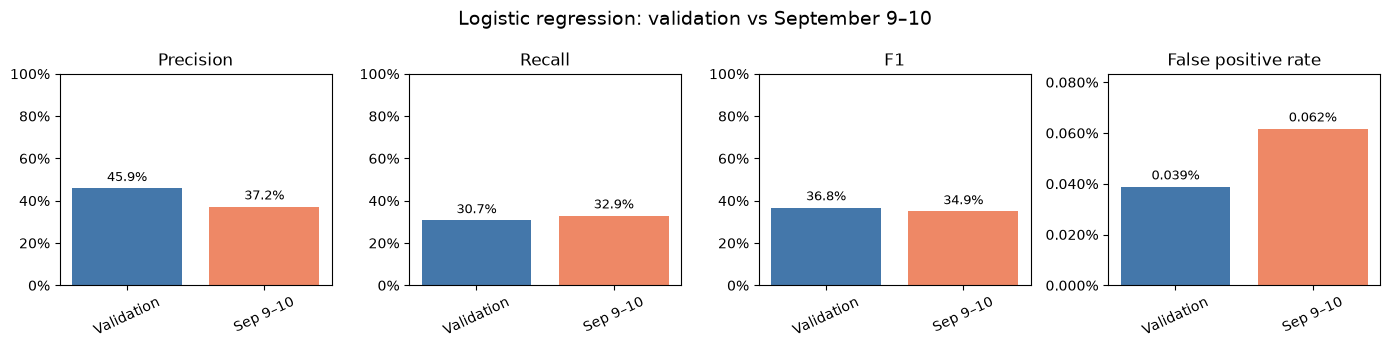

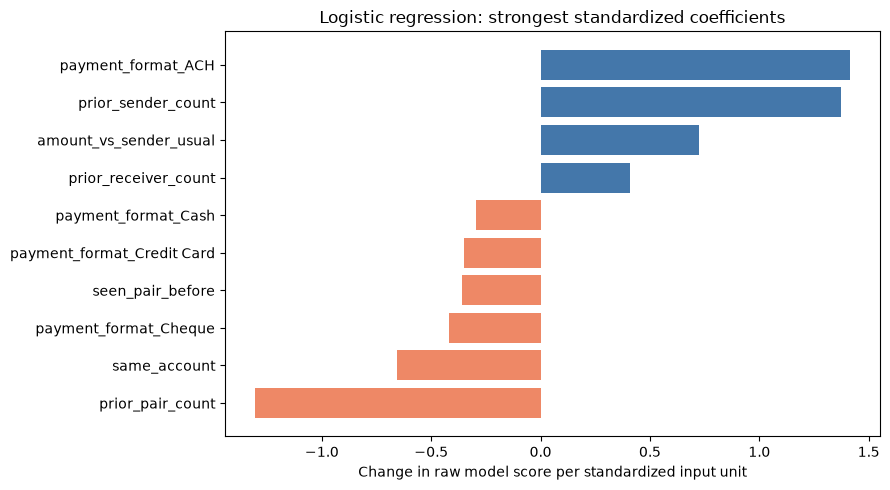

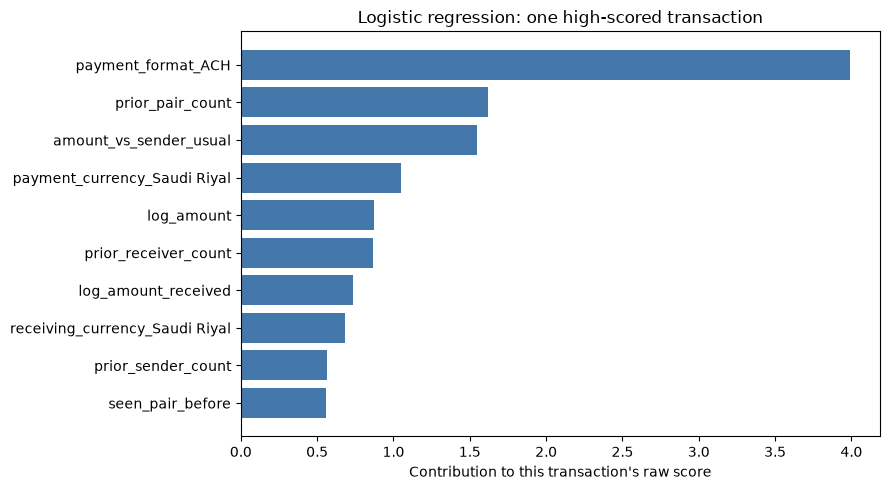

Example label: 1 | model score: 0.9915


In [11]:
show_model_scorecard("Logistic regression")

logistic_pipeline = models["Logistic regression"]
logistic = logistic_pipeline.named_steps["logisticregression"]
coefficients = pd.Series(logistic.coef_[0], index=X_train_logistic.columns)
strongest = coefficients.loc[coefficients.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(strongest.index, strongest, color=np.where(strongest >= 0, "#4477AA", "#EE8866"))
ax.set_title("Logistic regression: strongest standardized coefficients")
ax.set_xlabel("Change in raw model score per standardized input unit")
fig.tight_layout()
plt.show()

logistic_row = np.argmax(scores[("Logistic regression", "test")])
scaled_row = logistic_pipeline.named_steps["standardscaler"].transform(
    X_test_logistic.iloc[[logistic_row]]
)[0]
linear_parts = pd.Series(scaled_row * logistic.coef_[0], index=X_train_logistic.columns)
important_parts = linear_parts.loc[linear_parts.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(important_parts.index, important_parts,
        color=np.where(important_parts >= 0, "#4477AA", "#EE8866"))
ax.set_title("Logistic regression: one high-scored transaction")
ax.set_xlabel("Contribution to this transaction's raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(y_test.iloc[logistic_row]),
      "| model score:", round(float(scores[("Logistic regression", "test")][logistic_row]), 4))

### 9.2 XGBoost and Tree SHAP

XGBoost uses **120 shallow trees (depth 3)** and has the highest mean average precision across the three time folds. On September 9–10 it catches **379 of 956** positive labels in **537 alerts**: **70.6% precision**, **39.6% recall**, **0.508 F1**, and **0.018% FPR**. The full-test table also includes the September 11–18 tail, whose unusually high positive-label rate inflates the aggregate precision and average precision.

The **Tree SHAP** charts below show (1) average absolute feature effects across 500 later transactions and (2) signed effects for one high-scored transaction. XGBoost's built-in `pred_contribs=True` returns Tree SHAP contributions plus a bias term in raw score units. These explain model behavior, not why a transaction received its synthetic label. [XGBoost documents this output](https://xgboost.readthedocs.io/en/latest/python/python_api.html).


XGBoost — validation-selected threshold: 0.3704


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
0,validation,0.4738,0.7009,0.3890,0.5003,0.0002,575,403,172
1,test,0.5876,0.7983,0.4767,0.5970,0.0002,962,768,194
2,September 9–10,0.4625,0.7058,0.3964,0.5077,0.0002,537,379,158
3,September 11–18,0.9306,0.9153,0.5939,0.7204,0.0795,425,389,36


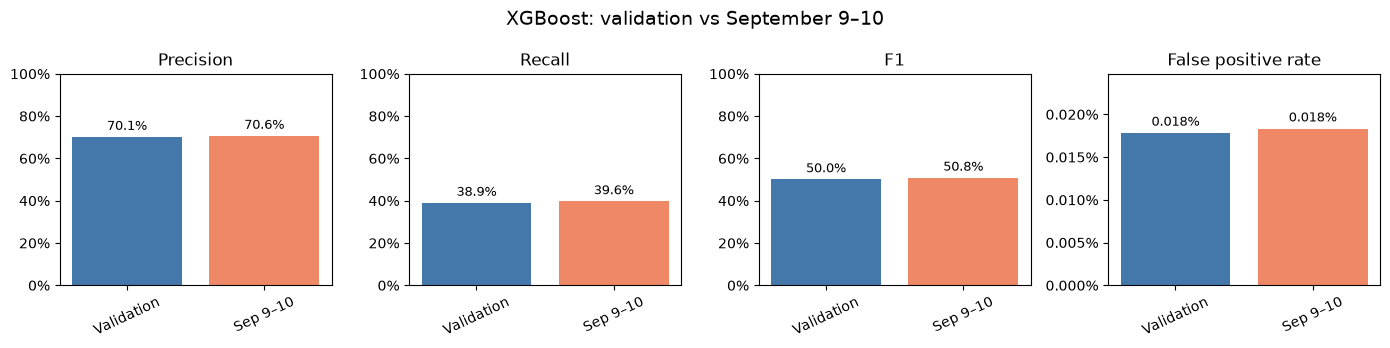

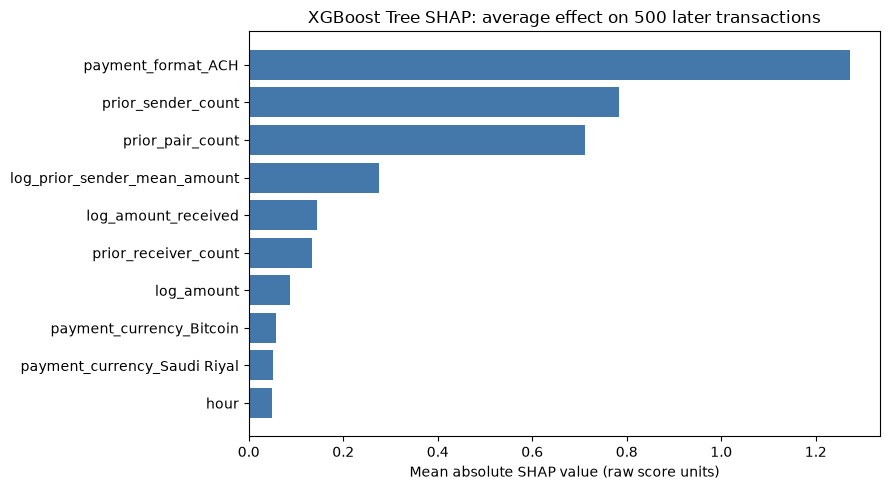

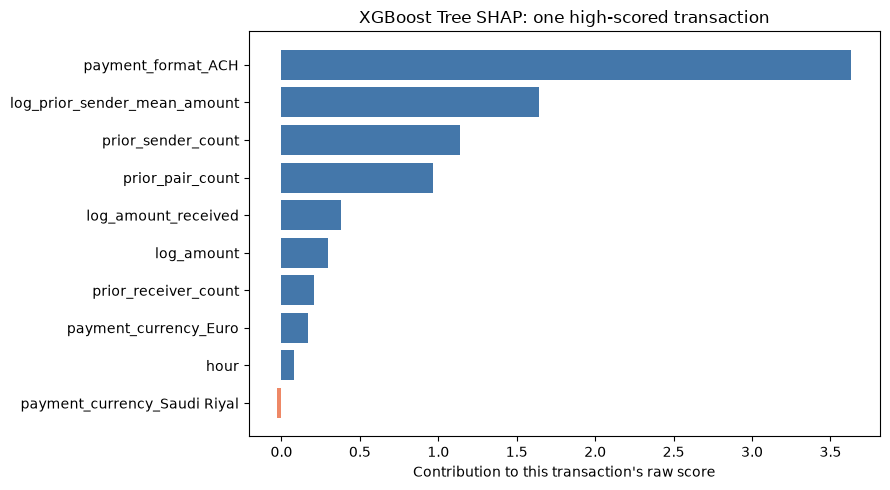

Example label: 1 | model score: 0.9684 | SHAP contributions plus bias: 3.4213


In [12]:
show_model_scorecard("XGBoost")

xgboost = models["XGBoost"]
booster = xgboost.get_booster()
shap_sample = X_test.sample(n=500, random_state=SEED)
shap_matrix = booster.predict(DMatrix(shap_sample), pred_contribs=True)
mean_abs_shap = pd.Series(
    np.abs(shap_matrix[:, :-1]).mean(axis=0), index=X_train.columns
)
top_global = mean_abs_shap.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_global.index, top_global, color="#4477AA")
ax.set_title("XGBoost Tree SHAP: average effect on 500 later transactions")
ax.set_xlabel("Mean absolute SHAP value (raw score units)")
fig.tight_layout()
plt.show()

xgb_row = np.argmax(scores[("XGBoost", "test")])
local_values = booster.predict(
    DMatrix(X_test.iloc[[xgb_row]]), pred_contribs=True
)[0]
local_shap = pd.Series(local_values[:-1], index=X_train.columns)
top_local = local_shap.loc[local_shap.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_local.index, top_local,
        color=np.where(top_local >= 0, "#4477AA", "#EE8866"))
ax.set_title("XGBoost Tree SHAP: one high-scored transaction")
ax.set_xlabel("Contribution to this transaction's raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(y_test.iloc[xgb_row]),
      "| model score:", round(float(scores[("XGBoost", "test")][xgb_row]), 4),
      "| SHAP contributions plus bias:", round(float(local_values.sum()), 4))

### 9.3 Explainable Boosting Machine (EBM)

EBM adds one learned effect per input, with **no interaction terms**. On September 9–10 it catches **298 of 956** positive labels in **377 alerts**: **79.0% precision**, **31.2% recall**, **0.447 F1**, and **0.009% FPR**. It is more selective than the other models at its validation-selected threshold and misses more known positives. The full-test table also shows the unusual September 11–18 tail.

The first chart shows which additive terms matter most overall. The second shows signed term effects for one high-scored transaction. These terms sum with the model's intercept to form its raw score. [InterpretML documents the term scores](https://interpret.ml/docs/python/api/ExplainableBoostingClassifier.html).


EBM — validation-selected threshold: 0.5312


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,false_positives
0,validation,0.4293,0.8201,0.3301,0.4708,0.0001,417,342,75
1,test,0.5301,0.8434,0.3743,0.5185,0.0001,715,603,112
2,September 9–10,0.4167,0.7905,0.3117,0.4471,0.0001,377,298,79
3,September 11–18,0.9264,0.9024,0.4656,0.6143,0.0728,338,305,33


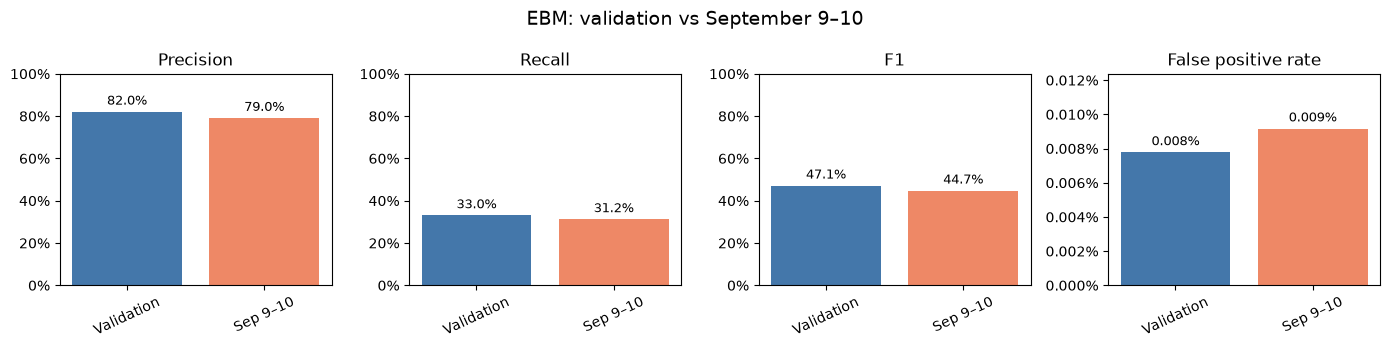

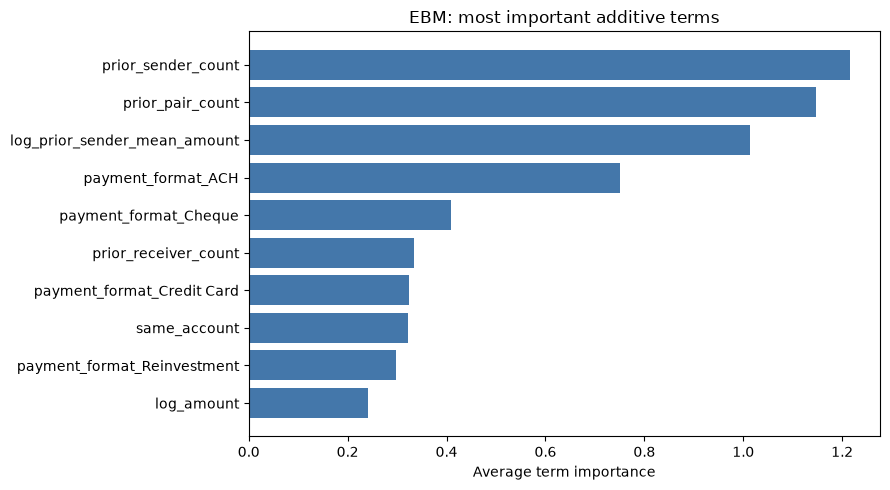

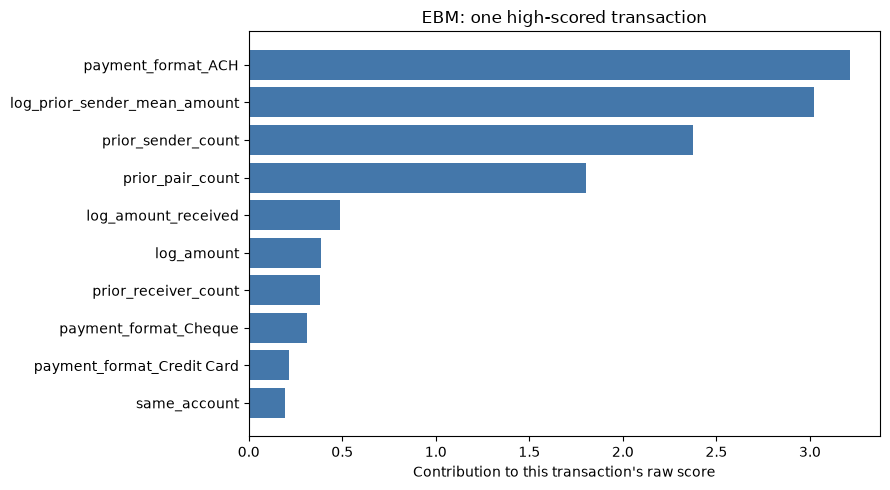

Example label: 1 | model score: 0.9928


In [13]:
show_model_scorecard("EBM")

ebm = models["EBM"]
importance = pd.Series(ebm.term_importances(), index=ebm.term_names_)
top_terms = importance.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_terms.index, top_terms, color="#4477AA")
ax.set_title("EBM: most important additive terms")
ax.set_xlabel("Average term importance")
fig.tight_layout()
plt.show()

ebm_row = np.argmax(scores[("EBM", "test")])
local_terms = pd.Series(ebm.eval_terms(X_test.iloc[[ebm_row]])[0], index=ebm.term_names_)
top_local_terms = local_terms.loc[local_terms.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_local_terms.index, top_local_terms,
        color=np.where(top_local_terms >= 0, "#4477AA", "#EE8866"))
ax.set_title("EBM: one high-scored transaction")
ax.set_xlabel("Contribution to this transaction's raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(y_test.iloc[ebm_row]),
      "| model score:", round(float(scores[("EBM", "test")][ebm_row]), 4))

## 10. What this MVP can claim

This notebook compares three understandable model families on **all 5,078,345 synthetic transactions** and a time-ordered split. Logistic regression uses log-scaled history counts and three simple behavior clues; XGBoost uses shallow trees with Tree SHAP; EBM uses additive effects without interactions. Every row contributes to strictly earlier account history and belongs to training, validation, or the later test.

On the ordinary September 9–10 test days, logistic regression gets **37.2% precision and 32.9% recall** in **847 alerts**; XGBoost gets **70.6% precision and 39.6% recall** in **537 alerts**; EBM gets **79.0% precision and 31.2% recall** in **377 alerts**. All three clear the illustrative 30% precision and recall goal, but the selected XGBoost model still misses **all positive non-ACH payments** in the later test. The subgroup table shows that coverage gap directly.

The September 11–18 tail has a drastically different label rate from earlier days. Read its results separately: the aggregate later-test score combines unlike populations. The later period was consulted during development, making these figures exploratory rather than an untouched final estimate. No score is a calibrated laundering probability; the CSV contains no investigator decisions or Suspicious Activity Report outcomes. The [project guide](docs/PROJECT_GUIDE.md) explains the metrics and AML context.
